# Введение
## Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
## Постановка задачи
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

5. Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# Описание датасета
[Concrete Compressive Strength Dataset](https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set)
Этот многомерный датасет содержит информацию о составе бетонных смесей и их возрасте для прогнозирования ключевого показателя качества — прочности на сжатие. Набор данных включает 1030 наблюдений с 8 признаками (количество цемента, шлака, золы-уноса, воды, пластификатора, крупного и мелкого заполнителя, а также возраст образца) и одной целевой переменной. Данные представлены в сыром виде и не содержат пропусков, что делает датасет готовым к использованию в задачах регрессионного анализа и машинного обучения.


|Название переменной|Тип данных|Единица измерения|Описание|Тип переменной|
|-|-|-|-|-|
|Cement|Числовая переменная|кг в м³ смеси|Количество цемента в смеси (Компонент 1)|Независимая|
|Blast Furnace Slag|Числовая переменная|кг в м³ смеси|Количество гранулированного доменного шлака (Компонент 2)|Независимая|
|Fly Ash|Числовая переменная|кг в м³ смеси|Количество золы-уноса (Компонент 3)|Независимая|
|Water|Числовая переменная|кг в м³ смеси|Количество воды (Компонент 4)|Независимая|
|Superplasticizer|Числовая переменная|кг в м³ смеси|Количество суперпластификатора (Компонент 5)|Независимая|
|Coarse Aggregate|Числовая переменная|кг в м³ смеси|Количество крупного заполнителя (Компонент 6)|Независимая|
|Fine Aggregate|Числовая переменная|кг в м³ смеси|Количество мелкого заполнителя (Компонент 7)|Независимая|
|Age|Числовая переменная|День (1-365)|Возраст бетона на момент испытания|Независимая|
|Concrete compressive strength|Числовая переменная|Мегапаскали (МПа)|Прочность бетона на сжатие|Зависимая|


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import kagglehub
import math
import scipy.stats as stats

# Загрузка данных
file_path = "concrete_data.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "elikplim/concrete-compressive-strength-data-set",
  file_path,
)

display(df.head())

c:\Users\bulch\OneDrive\Desktop\Нейронки\ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Графики распределения признаков
Расчет количества интервалов по формуле Стержиса

In [3]:
# Функция для построения гистограммы распределения признаков и вывода стастистики
def print_stats(dataframe, feature_name, k):
    plt.hist(dataframe[feature_name], bins=k, edgecolor='black')
    plt.title(f'Распределение признака {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Частота')

    shapiro_test = stats.shapiro(dataframe[feature_name])
    dagostino_test = stats.normaltest(dataframe[feature_name])
    ks_test = stats.kstest(
        dataframe[feature_name],
        'norm',
        args=(dataframe[feature_name].mean(), dataframe[feature_name].std())
    )

    def interpret_pvalue(p):
        if p > 0.05:
            return "Нормальное"
        elif p > 0.01:
            return "Близко к нормальному"
        else:
            return "Далеко от нормального"
    

    # Дескриптивный анализ
    print (
        f"Статистика для признака {feature_name}:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Среднее:                  | {dataframe[feature_name].mean()}\n"
        f"Медиана:                  | {dataframe[feature_name].median()}\n"
        f"Мода:                     | {dataframe[feature_name].mode()[0]}\n"
        f"Минимум:                  | {dataframe[feature_name].min()}\n"
        f"Максимум:                 | {dataframe[feature_name].max()}\n"
        f"Размах:                   | {dataframe[feature_name].max() - dataframe[feature_name].min()}\n"
        f"Стандартное отклонение:   | {dataframe[feature_name].std()}\n"
        f"Дисперсия:                | {dataframe[feature_name].var()}\n"
        f"Асимметрия:               | {dataframe[feature_name].skew()}\n"
        f"Эксцесс:                  | {dataframe[feature_name].kurtosis()}\n"
        f"Квантили (25%, 50%, 75%): | {dataframe[feature_name].quantile([0.25, 0.5, 0.75]).to_dict()}\n"
        f"Оценка нормальности распредления:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Шапиро-Уилк:              | p={shapiro_test.pvalue:.3e} → {interpret_pvalue(shapiro_test.pvalue)}\n"
        f"Д'Агостино-Пиросона:      | p={dagostino_test.pvalue:.3e} → {interpret_pvalue(dagostino_test.pvalue)}\n"
        f"Колмагорова-Смирнова      | p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}\n"
    )



n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))
print(f"Количество записей: {n}")
print(f"Количество интервалов по формуле Стержиса: {k}")

Количество записей: 1030
Количество интервалов по формуле Стержиса: 12


### Анализ параметра Cement (Количество цемента в смеси)

Статистика для признака cement:
--------------------------|-------------------------------------------
Среднее:                  | 281.16786407766995
Медиана:                  | 272.9
Мода:                     | 362.6
Минимум:                  | 102.0
Максимум:                 | 540.0
Размах:                   | 438.0
Стандартное отклонение:   | 104.50636449481532
Дисперсия:                | 10921.580219923197
Асимметрия:               | 0.509481178871773
Эксцесс:                  | -0.5206522844987744
Квантили (25%, 50%, 75%): | {0.25: 192.375, 0.5: 272.9, 0.75: 350.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.082e-16 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.882e-14 → Далеко от нормального
Колмагорова-Смирнова      | p=5.625e-06 → Далеко от нормального



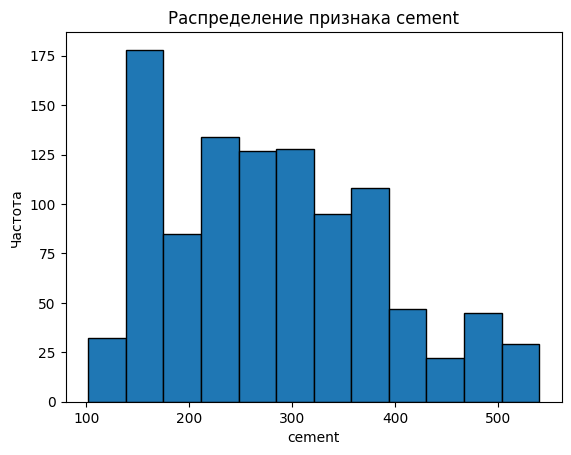

In [4]:
print_stats(df, 'cement', k)

Расперделение является плосковершинным и имеет правосторонную ассиметрию. Между медианой и средней имеется разница, а так же большая разница с модой.  
На основе результатов тестов и анализа распределение не явялется нормальным.


### Анализ параметра Blast Furnace Slag (Количество гранулированного доменного шлака)

Статистика для признака blast_furnace_slag:
--------------------------|-------------------------------------------
Среднее:                  | 73.89582524271846
Медиана:                  | 22.0
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 359.4
Размах:                   | 359.4
Стандартное отклонение:   | 86.27934174810584
Дисперсия:                | 7444.124812486438
Асимметрия:               | 0.8007168956061772
Эксцесс:                  | -0.5081754788835449
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 22.0, 0.75: 142.95}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=5.796e-33 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.314e-24 → Далеко от нормального
Колмагорова-Смирнова      | p=1.368e-62 → Далеко от нормального



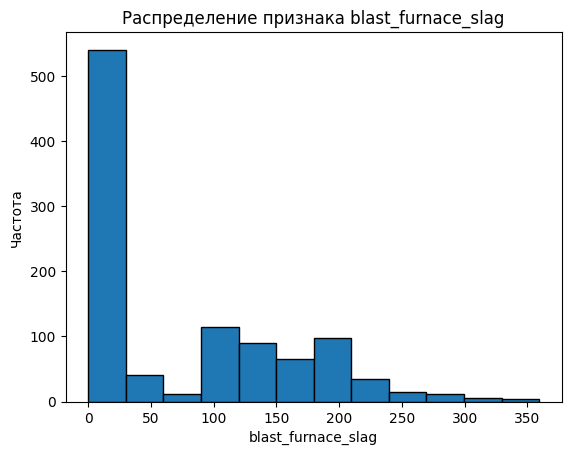

In [5]:
print_stats(df, 'blast_furnace_slag', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется значительная разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Fly Ash (Количество золы-уноса)

Статистика для признака fly_ash:
--------------------------|-------------------------------------------
Среднее:                  | 54.18834951456311
Медиана:                  | 0.0
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 200.1
Размах:                   | 200.1
Стандартное отклонение:   | 63.99700415268765
Дисперсия:                | 4095.6165405191205
Асимметрия:               | 0.5373539058066844
Эксцесс:                  | -1.3287464346799722
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 0.0, 0.75: 118.3}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=4.135e-36 → Далеко от нормального
Д'Агостино-Пиросона:      | p=0.000e+00 → Далеко от нормального
Колмагорова-Смирнова      | p=6.355e-114 → Далеко от нормального



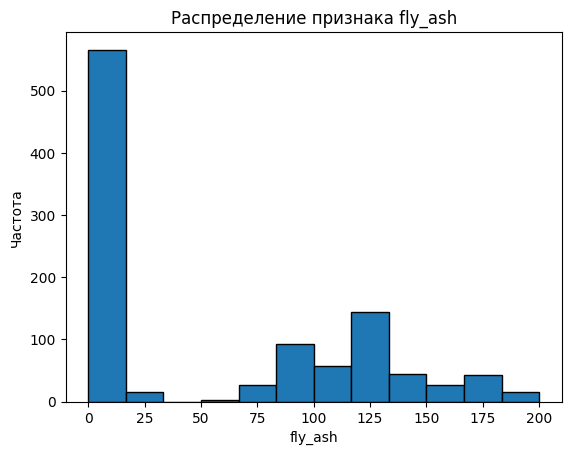

In [6]:
print_stats(df, 'fly_ash', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется значительная разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Water (Количество воды)

Статистика для признака water:
--------------------------|-------------------------------------------
Среднее:                  | 181.56728155339806
Медиана:                  | 185.0
Мода:                     | 192.0
Минимум:                  | 121.8
Максимум:                 | 247.0
Размах:                   | 125.2
Стандартное отклонение:   | 21.35421856503247
Дисперсия:                | 456.00265052317735
Асимметрия:               | 0.07462838428549402
Эксцесс:                  | 0.1220816743945825
Квантили (25%, 50%, 75%): | {0.25: 164.9, 0.5: 185.0, 0.75: 192.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.463e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.349e-01 → Нормальное
Колмагорова-Смирнова      | p=2.712e-05 → Далеко от нормального



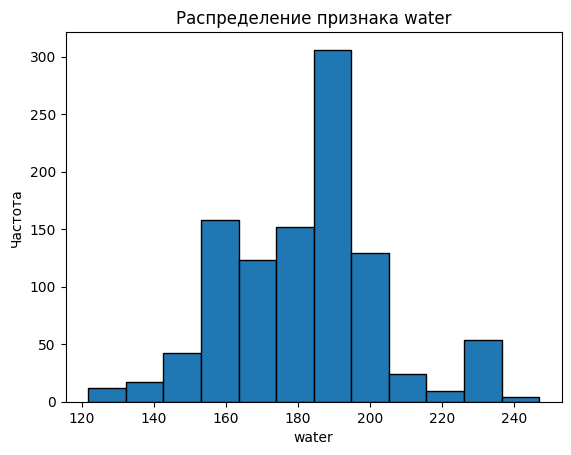

In [7]:
print_stats(df, 'water', k)

Распределение имеет почти нулевую ассиметрию (наблюдается небольшая правосторонняя ассиметрия). Между медианой, средним и модой имеется небольшая разница.  
Распределение признака близко к нормальному, но не идеально нормальное из-за выбросов.

### Анализ параметра Superplasticizer (Количество суперпластификатора)

Статистика для признака superplasticizer:
--------------------------|-------------------------------------------
Среднее:                  | 6.204660194174758
Медиана:                  | 6.4
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 32.2
Размах:                   | 32.2
Стандартное отклонение:   | 5.97384139248552
Дисперсия:                | 35.68678098257333
Асимметрия:               | 0.9072025748672465
Эксцесс:                  | 1.4112689653489738
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 6.4, 0.75: 10.2}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=9.065e-29 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.459e-31 → Далеко от нормального
Колмагорова-Смирнова      | p=1.199e-43 → Далеко от нормального



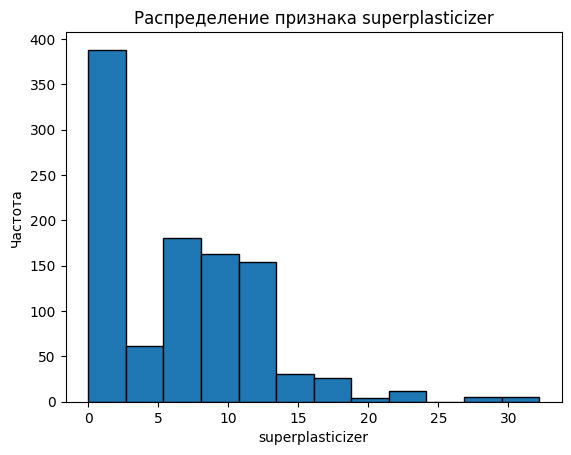

In [8]:
print_stats(df, 'superplasticizer', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Coarse Aggregate (Количество крупного заполнителя)

Статистика для признака coarse_aggregate:
--------------------------|-------------------------------------------
Среднее:                  | 972.9189320388349
Медиана:                  | 968.0
Мода:                     | 932.0
Минимум:                  | 801.0
Максимум:                 | 1145.0
Размах:                   | 344.0
Стандартное отклонение:   | 77.75395396672077
Дисперсия:                | 6045.677357458932
Асимметрия:               | -0.04021974481106706
Эксцесс:                  | -0.5990161032185637
Квантили (25%, 50%, 75%): | {0.25: 932.0, 0.5: 968.0, 0.75: 1029.4}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=8.347e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=8.455e-08 → Далеко от нормального
Колмагорова-Смирнова      | p=4.311e-04 → Далеко от нормального



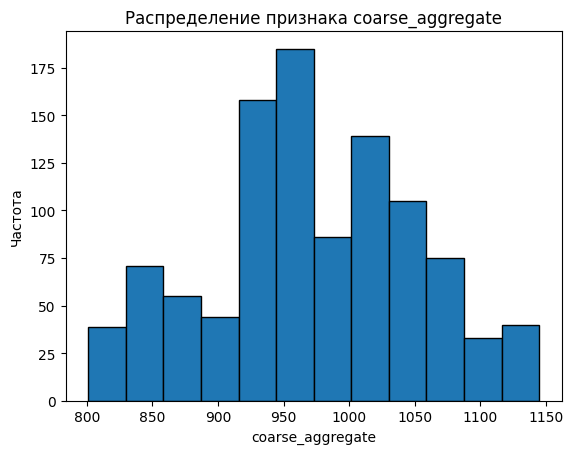

In [9]:
print_stats(df, 'coarse_aggregate', k)

Распределение имеет незначительую асимметрию, значения среднего, моды и медианы достаточно близки, но распределение является плосковершинным.  
Распределение близко к нормальному, но из-за значения эксцесса его таким назвать нельзя.

### Анализ параметра Fine Aggregate (Количество мелкого заполнителя)

Статистика для признака fine_aggregate :
--------------------------|-------------------------------------------
Среднее:                  | 773.5804854368932
Медиана:                  | 779.5
Мода:                     | 594.0
Минимум:                  | 594.0
Максимум:                 | 992.6
Размах:                   | 398.6
Стандартное отклонение:   | 80.17598014240437
Дисперсия:                | 6428.18779179522
Асимметрия:               | -0.25300959769707576
Эксцесс:                  | -0.10217698932117791
Квантили (25%, 50%, 75%): | {0.25: 730.95, 0.5: 779.5, 0.75: 824.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.842e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.714e-03 → Далеко от нормального
Колмагорова-Смирнова      | p=4.938e-07 → Далеко от нормального



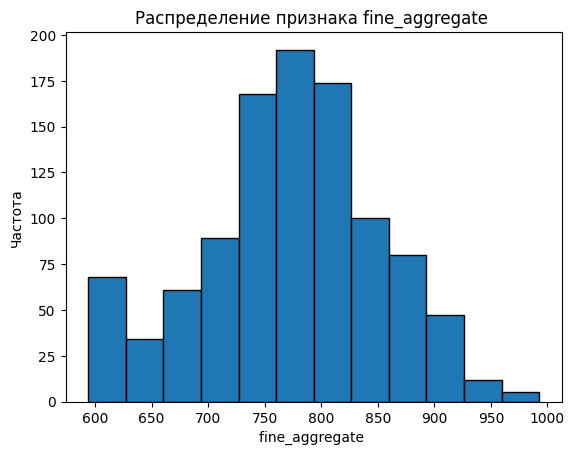

In [10]:
print_stats(df, 'fine_aggregate ', k)

### Анализ параметра Age (Возраст бетона на момент испытания)

Статистика для признака age:
--------------------------|-------------------------------------------
Среднее:                  | 45.662135922330094
Медиана:                  | 28.0
Мода:                     | 28
Минимум:                  | 1
Максимум:                 | 365
Размах:                   | 364
Стандартное отклонение:   | 63.16991158103249
Дисперсия:                | 3990.437729155462
Асимметрия:               | 3.26917740063459
Эксцесс:                  | 12.168988978672088
Квантили (25%, 50%, 75%): | {0.25: 7.0, 0.5: 28.0, 0.75: 56.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=7.718e-44 → Далеко от нормального
Д'Агостино-Пиросона:      | p=1.071e-158 → Далеко от нормального
Колмагорова-Смирнова      | p=5.019e-105 → Далеко от нормального



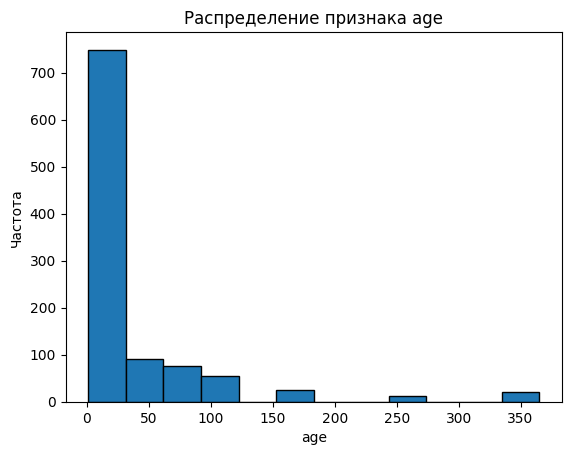

In [11]:
print_stats(df, 'age', k)

### Анализ параметра Concrete compressive strength (Прочность бетона на сжатие)

Статистика для признака concrete_compressive_strength:
--------------------------|-------------------------------------------
Среднее:                  | 35.817961165048544
Медиана:                  | 34.445
Мода:                     | 33.4
Минимум:                  | 2.33
Максимум:                 | 82.6
Размах:                   | 80.27
Стандартное отклонение:   | 16.705741961912512
Дисперсия:                | 279.08181449800446
Асимметрия:               | 0.416977288410718
Эксцесс:                  | -0.3137248604469969
Квантили (25%, 50%, 75%): | {0.25: 23.71, 0.5: 34.445, 0.75: 46.135000000000005}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=9.010e-11 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.937e-08 → Далеко от нормального
Колмагорова-Смирнова      | p=5.815e-02 → Нормальное



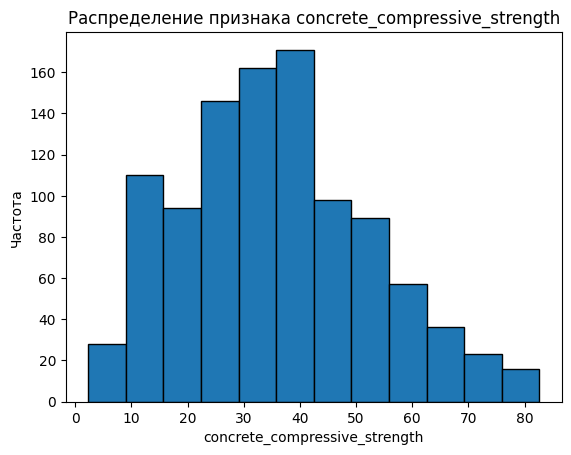

In [12]:
print_stats(df, 'concrete_compressive_strength', k)

# Подготовка данных
В датасете отсутвуют категориальные переменные. Так же в нем отсутвуют пустые значения:

In [13]:
print(f"Количество пропущенных значений: {df.isnull().sum().sum()}")

Количество пропущенных значений: 0


## Разделение выборки на train/test и стандартизация

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

x = df.drop(columns=['concrete_compressive_strength'])
y = df['concrete_compressive_strength']

# Стандартизация признаков
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#  Критерий КМО

In [72]:
kmo_all, kmo_model = calculate_kmo(x_scaled)
print("KMO по переменным:")
print(pd.Series(kmo_all, index=x.columns))
print("\nKMO по модели (общий показатель):", round(kmo_model, 3))

KMO по переменным:
cement                0.085215
blast_furnace_slag    0.095188
fly_ash               0.141909
water                 0.220105
superplasticizer      0.625285
coarse_aggregate      0.066503
fine_aggregate        0.113723
age                   0.794332
dtype: float64

KMO по модели (общий показатель): 0.153


# Критерий Бартлетта

In [73]:
chi_square_value, p_value = calculate_bartlett_sphericity(x_scaled)
print("\nКритерий Бартлетта:")
print("Chi-square =", round(chi_square_value, 3))
print("p-value    =", p_value)


Критерий Бартлетта:
Chi-square = 4141.257
p-value    = 0.0


# Что-то типа вывода 
Вывод по критериям КМО и Бартлетта
Для оценки пригодности выбранного набора признаков бетонной смеси к факторному анализу были рассчитаны критерий Кайзера–Мейера–Олкина (KMO) и критерий Бартлетта.
По критерию Бартлетта получено значение статистики
χ² = 4141.26 при p-value ≈ 0.0.
Это позволяет отвергнуть нулевую гипотезу о том, что корреляционная матрица не отличается от единичной. Следовательно, между признаками существуют статистически значимые корреляционные связи, и с точки зрения критерия Бартлетта применение факторного анализа формально допустимо.
В то же время общий показатель KMO для рассматриваемого набора признаков составил всего 0.153, что существенно ниже рекомендованного порога 0.5. Индивидуальные значения KMO для большинства переменных также низкие (в диапазоне примерно 0.07–0.22), за исключением признаков superplasticizer (KMO ≈ 0.63) и особенно age (KMO ≈ 0.79), для которых значения критерия находятся на удовлетворительном и хорошем уровне соответственно. Это означает, что:


только часть переменных (прежде всего age и в меньшей степени superplasticizer) может быть адекватно описана общими факторами;


для остальных переменных доля общей дисперсии, потенциально объясняемой скрытыми факторами, невелика.


Таким образом, в целом исходный набор признаков по критерию KMO считается неблагоприятным для факторного анализа, несмотря на статистически значимую корреляционную структуру по критерию Бартлетта. В дальнейших разделах факторный анализ будет выполнен в учебных целях для иллюстрации метода, а полученные результаты необходимо интерпретировать с осторожностью, учитывая низкое значение общего показателя KMO.


# Построение матрицы корреляции

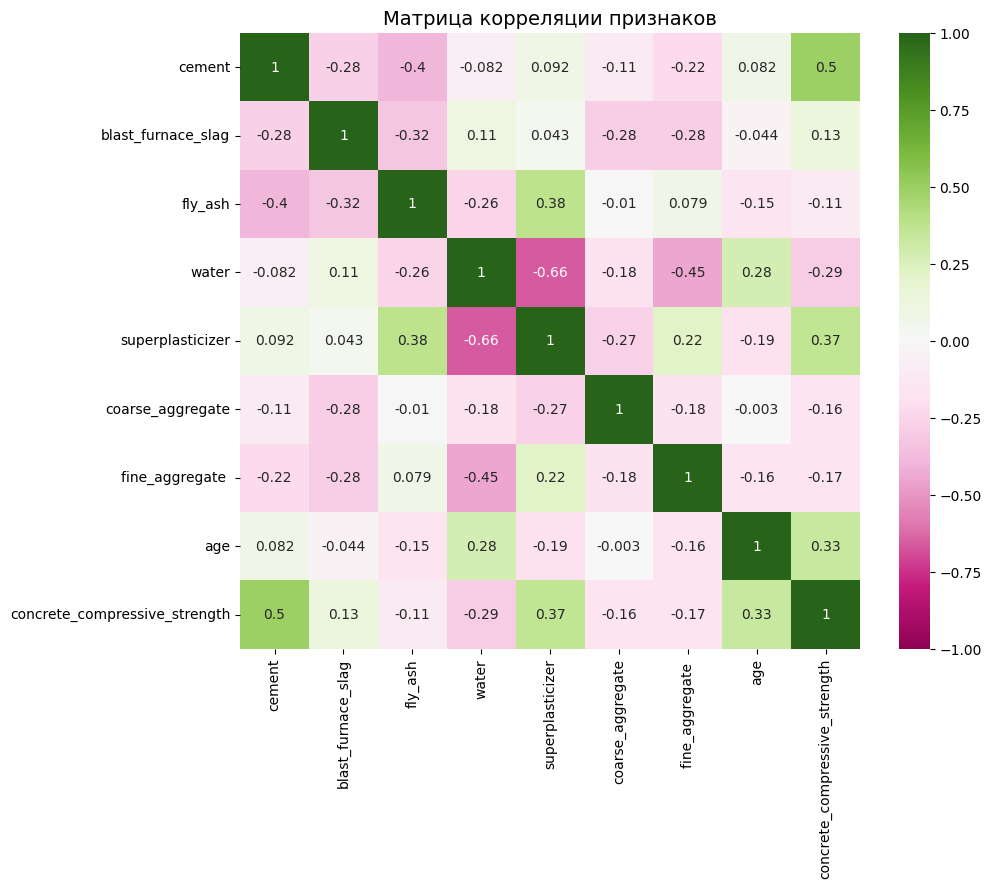

In [74]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков", fontsize=14)
plt.show()

Наблюдаем умереренную зависимость переменной concrete_compressive_strength с переменными cement, superplasticizer, age.

# Определение факторов методом главных компонент. Критерий Кайзера

In [96]:
from sklearn.decomposition import PCA

feature_cols = df.drop(columns=["concrete_compressive_strength"]).columns.tolist()

pca = PCA()
pca.fit(x_scaled)

eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_
cum_variance_ratio = np.cumsum(variance_ratio)

pca_components = pd.DataFrame(
    pca.components_,                
    columns=df.drop(columns=['concrete_compressive_strength']).columns,        
    index=[f'PC{i+1}' for i in range(pca.n_components_)]  
)

display(pca_components.round(3))

pca_table = pd.DataFrame(
    {
        "Собственное значение (λ)": eigenvalues,
    },
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

display(pca_table)

n_factors_kaiser = np.sum(eigenvalues > 1)
print(f"Число факторов по критерию Кайзера (λ > 1): {n_factors_kaiser}")

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
PC1,0.098,0.177,-0.395,0.547,-0.506,0.038,-0.402,0.291
PC2,-0.114,0.686,-0.143,0.053,0.283,-0.630,-0.019,-0.126
PC3,0.814,-0.172,-0.408,-0.213,0.235,-0.174,-0.005,0.101
PC4,0.054,0.363,-0.227,-0.296,0.037,0.546,-0.385,-0.528
PC5,-0.148,0.021,-0.550,-0.070,-0.355,0.033,0.701,-0.228
PC6,-0.203,0.305,-0.183,-0.366,0.193,0.315,0.092,0.744
PC7,-0.222,-0.228,-0.352,0.524,0.665,0.227,0.039,-0.069
PC8,0.446,0.437,0.382,0.389,0.052,0.349,0.433,0.013


,Собственное значение (λ)
PC1,2.282315
PC2,1.417451
PC3,1.341381
PC4,1.015144
PC5,0.952433
PC6,0.790963
PC7,0.178015
PC8,0.030072


Число факторов по критерию Кайзера (λ > 1): 4


# Изменение факторных нагрузок методом вращения

## До вращения

Матрица факторных нагрузок (до вращения):


c:\Users\bulch\OneDrive\Desktop\Нейронки\ML\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2,Factor3,Factor4
cement,-0.149,0.135,0.943,-0.055
blast_furnace_slag,-0.268,-0.816,-0.199,-0.365
fly_ash,0.596,0.170,-0.473,0.228
water,-0.826,-0.063,-0.247,0.298
superplasticizer,0.764,-0.337,0.272,-0.038
coarse_aggregate,-0.057,0.750,-0.202,-0.550
fine_aggregate,0.607,0.023,-0.005,0.388
age,-0.440,0.150,0.116,0.532


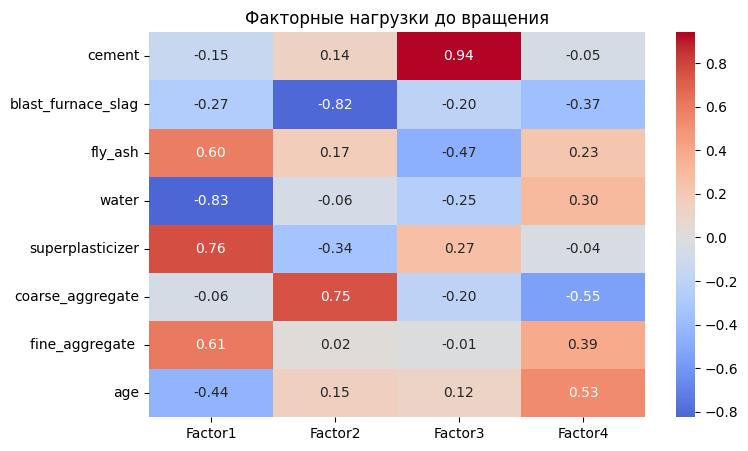

In [98]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


feature_cols = df.drop(columns=["concrete_compressive_strength"]).columns.tolist()

n_factors = 4

fa = FactorAnalyzer(n_factors=n_factors, rotation=None, method='principal')
fa.fit(x_scaled)  

loadings_no_rot = pd.DataFrame(
    fa.loadings_,
    index=feature_cols,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Матрица факторных нагрузок (до вращения):")
display(loadings_no_rot.round(3))

plt.figure(figsize=(8, 5))
sns.heatmap(loadings_no_rot,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0)
plt.title("Факторные нагрузки до вращения")
plt.yticks(rotation=0)
plt.show()

## После вращения

Матрица факторных нагрузок (после вращения varimax):


c:\Users\bulch\OneDrive\Desktop\Нейронки\ML\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2,Factor3,Factor4
cement,0.085,0.198,0.940,0.047
blast_furnace_slag,0.031,-0.922,-0.073,0.233
fly_ash,0.269,0.382,-0.664,0.032
water,-0.879,-0.245,-0.015,0.057
superplasticizer,0.782,0.092,-0.004,0.390
coarse_aggregate,0.027,0.153,-0.041,-0.939
fine_aggregate,0.335,0.468,-0.267,0.342
age,-0.612,0.259,0.167,0.207


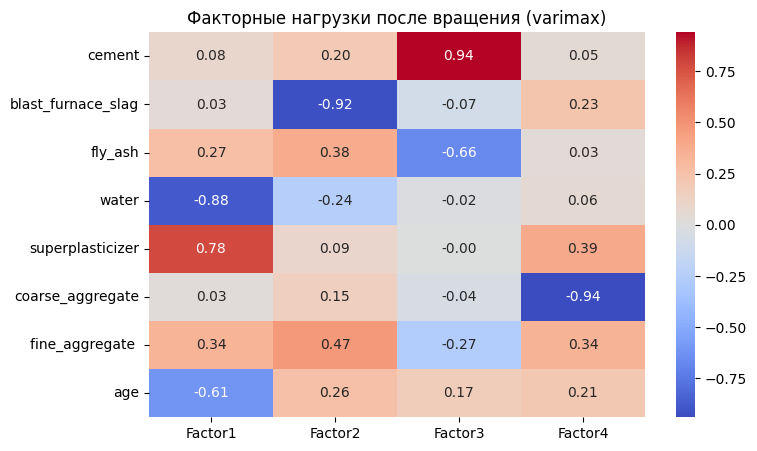

cement                0.932
blast_furnace_slag    0.911
fly_ash               0.660
water                 0.836
superplasticizer      0.772
coarse_aggregate      0.908
fine_aggregate        0.519
age                   0.512
Name: Communality, dtype: float64

In [99]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


n_factors = 4  


fa_rot = FactorAnalyzer(
    n_factors=n_factors,
    method='principal',
    rotation='varimax'
)
fa_rot.fit(x_scaled)


loadings_rot = pd.DataFrame(
    fa_rot.loadings_,
    index=feature_cols,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Матрица факторных нагрузок (после вращения varimax):")
display(loadings_rot.round(3))


plt.figure(figsize=(8, 5))
sns.heatmap(
    loadings_rot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Факторные нагрузки после вращения (varimax)")
plt.yticks(rotation=0)
plt.show()


communalities = pd.Series(
    fa_rot.get_communalities(),
    index=feature_cols,
    name="Communality"
)
display(communalities.round(3))


- Фактор 1 описывает технологический режим и соотношение вода / добавки / возраст образца.
- Фактор 2 связан с содержанием доменного шлака как минеральной добавки.
- Фактор 3 отражает баланс между содержанием цемента и золы-уноса (тип вяжущего).
- Фактор 4 характеризует структуру заполнителя, в первую очередь долю крупного заполнителя.

# Диаграмма рассеивания факторов

c:\Users\bulch\OneDrive\Desktop\Нейронки\ML\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2,Factor3,Factor4,concrete_compressive_strength
0,0.473179,0.347862,2.347441,-1.380031,79.99
1,0.492442,0.352764,2.344522,-1.527830,61.89
2,-2.873888,-0.383658,0.918719,0.811634,40.27
3,-3.473048,0.087544,1.007326,1.211692,41.05
4,-2.593973,0.982234,-0.148616,1.285610,44.30


C:\Users\bulch\AppData\Local\Temp\ipykernel_2460\3925577225.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")  # не синий, красивый градиент
C:\Users\bulch\AppData\Local\Temp\ipykernel_2460\3925577225.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


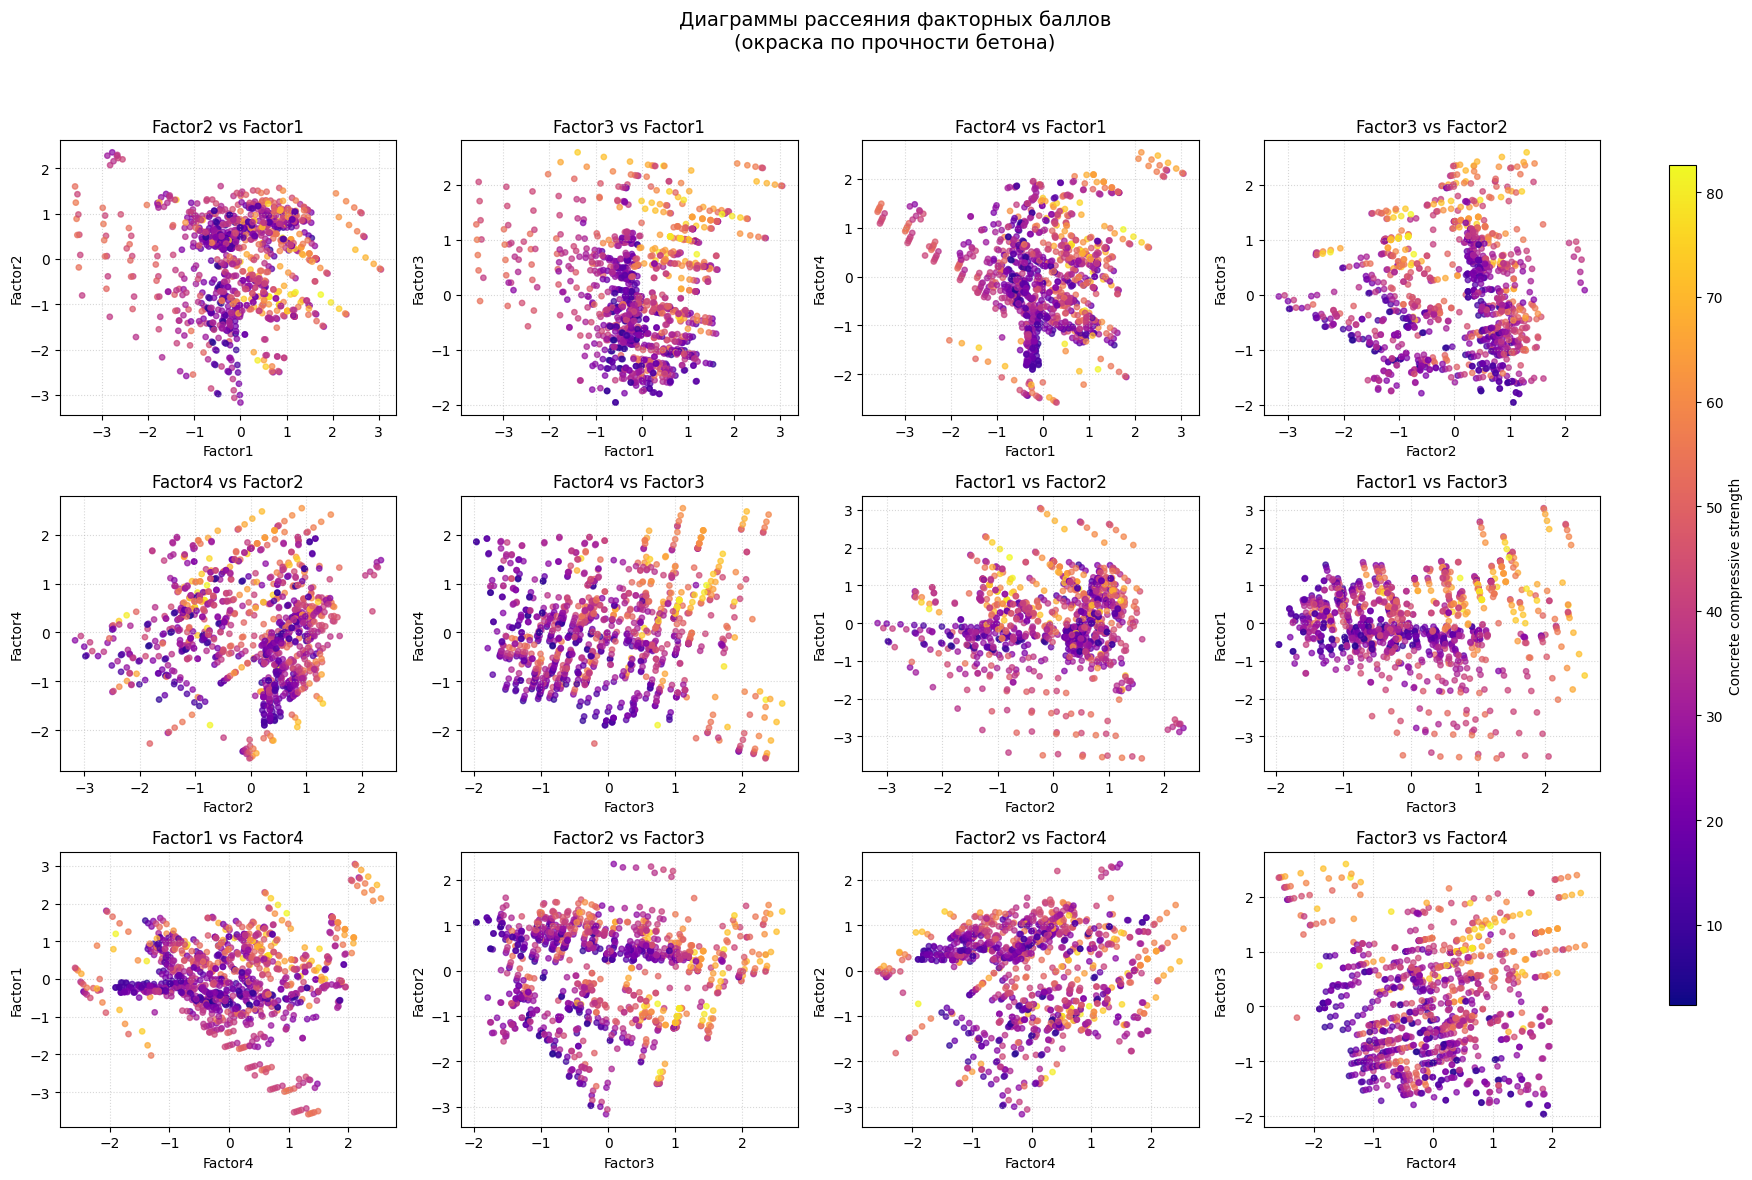

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

TARGET_COL = "concrete_compressive_strength"

# 1. Факторные баллы (используем твой x_scaled)
factor_scores = fa_rot.transform(x_scaled)
n_factors = factor_scores.shape[1]
factor_cols = [f"Factor{i+1}" for i in range(n_factors)]

scores_df = pd.DataFrame(factor_scores, columns=factor_cols)
scores_df[TARGET_COL] = df[TARGET_COL].values

display(scores_df.head())

# 2. Задаём пары факторов для 12 графиков (3 строки × 4 столбца)
pairs = [
    ("Factor1", "Factor2"),
    ("Factor1", "Factor3"),
    ("Factor1", "Factor4"),
    ("Factor2", "Factor3"),
    ("Factor2", "Factor4"),
    ("Factor3", "Factor4"),
    ("Factor2", "Factor1"),
    ("Factor3", "Factor1"),
    ("Factor4", "Factor1"),
    ("Factor3", "Factor2"),
    ("Factor4", "Factor2"),
    ("Factor4", "Factor3"),
]

# 3. Цвет по прочности бетона
strength = scores_df[TARGET_COL].values
norm = Normalize(vmin=strength.min(), vmax=strength.max())
cmap = cm.get_cmap("plasma")  # не синий, красивый градиент
colors = cmap(norm(strength))

# 4. Рисуем матрицу 3×4
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, (fx, fy) in zip(axes.ravel(), pairs):
    ax.scatter(
        scores_df[fx],
        scores_df[fy],
        c=colors,
        s=15,
        alpha=0.7
    )
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f"{fy} vs {fx}")
    ax.grid(True, linestyle=":", alpha=0.5)

# 5. Общая цветовая шкала
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Concrete compressive strength")

plt.suptitle("Диаграммы рассеяния факторных баллов\n(окраска по прочности бетона)", y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
